In [1]:
"""
Cell 1: Environment Verification

Purpose:
--------
Before doing any preprocessing, we must confirm that:

1. The notebook is using our project virtual environment (.venv)
2. We are NOT using the system Python
3. The Python version is correct

Why this matters:
-----------------
If we accidentally use system Python:
- Packages may mismatch
- PyTorch may install incorrectly later
- Reproducibility breaks
- Debugging becomes painful

This check ensures we are working inside:
Luftwächter(multisite_transformer)/.venv
"""

import sys

print("Python executable path:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable path:
/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)/.venv/bin/python

Python version:
3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:
"""
Cell 2: Load the train/val/test splits file

Purpose:
--------
We created a time-ordered split earlier and saved it as a .npz file.
Now we will:

1) Build the file path to the saved .npz
2) Check the file exists (prevents silent path bugs)
3) Load the arrays
4) Print shapes to confirm everything is correct

No normalization happens in this cell.
"""

import os
import numpy as np

# NOTE:
# In a notebook, the "current working directory" may not be the project root.
# So we build the path safely.

# Option 1 (recommended): Set PROJECT_ROOT manually once
PROJECT_ROOT = "/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)"

SPLITS_PATH = os.path.join(
    PROJECT_ROOT, "data", "processed", "splits_Tin24_Tout6_stride1.npz"
)

print("SPLITS_PATH:", SPLITS_PATH)
print("File exists?", os.path.exists(SPLITS_PATH))

# Load the file
data = np.load(SPLITS_PATH, allow_pickle=True)

# Extract arrays
X_train = data["X_train"]
Y_train = data["Y_train"]
X_val   = data["X_val"]
Y_val   = data["Y_val"]
X_test  = data["X_test"]
Y_test  = data["Y_test"]

X_mask_train = data["X_mask_train"]
Y_mask_train = data["Y_mask_train"]

feature_cols = list(data["feature_cols"])
target_cols  = list(data["target_cols"])

print("\nShapes:")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

print("\nFeatures:", feature_cols)
print("Targets :", target_cols)

SPLITS_PATH: /Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)/data/processed/splits_Tin24_Tout6_stride1.npz
File exists? True

Shapes:
X_train: (21182, 24, 7, 14) Y_train: (21182, 6, 7, 2)
X_val  : (4539, 24, 7, 14) Y_val  : (4539, 6, 7, 2)
X_test : (4539, 24, 7, 14) Y_test : (4539, 6, 7, 2)

Features: ['year', 'month', 'day', 'hour', 'O3_forecast', 'NO2_forecast', 'T_forecast', 'q_forecast', 'u_forecast', 'v_forecast', 'w_forecast', 'NO2_satellite', 'HCHO_satellite', 'ratio_satellite']
Targets : ['O3_target', 'NO2_target']


In [3]:
"""
Cell 3: Fit Global Normalization (StandardScaler) on TRAIN only

Purpose:
--------
We need to normalize features so training is stable.
Correct rule for time-series ML:

1) Fit mean/std ONLY on training set
2) Apply the same mean/std to val and test (later cell)
3) Use masks so missing values don't affect stats

Output:
-------
mean_x: (F,) mean per feature
std_x : (F,) std per feature
"""

import numpy as np

def fit_global_standard_scaler(X, X_mask, eps=1e-6):
    """
    Compute mean and std per feature using only valid values (mask==1).

    X shape:      (N, Tin, S, F)
    X_mask shape: (N, Tin, S, F)

    Returns:
      mean: (F,)
      std : (F,)
    """
    # Flatten all dims except feature dim -> (N*Tin*S, F)
    X_flat = X.reshape(-1, X.shape[-1])
    M_flat = X_mask.reshape(-1, X_mask.shape[-1])

    F = X.shape[-1]
    mean = np.zeros((F,), dtype=np.float32)
    std  = np.ones((F,), dtype=np.float32)

    for f in range(F):
        valid = M_flat[:, f] > 0.5
        vals = X_flat[valid, f]

        if vals.size == 0:
            # If a feature has no valid values at all (rare), keep neutral scaling
            mean[f] = 0.0
            std[f] = 1.0
        else:
            mean[f] = vals.mean().astype(np.float32)
            s = vals.std().astype(np.float32)
            std[f] = s if s > eps else 1.0

    return mean, std

mean_x, std_x = fit_global_standard_scaler(X_train, X_mask_train)

print("mean_x shape:", mean_x.shape)
print("std_x  shape:", std_x.shape)

print("\nPer-feature stats:")
for i, name in enumerate(feature_cols):
    print(f"{i:02d} {name:>15} | mean={mean_x[i]: .4f}  std={std_x[i]: .4f}")

mean_x shape: (14,)
std_x  shape: (14,)

Per-feature stats:
00            year | mean= 2020.7181  std= 1.0401
01           month | mean= 6.9949  std= 3.3679
02             day | mean= 15.6658  std= 8.8620
03            hour | mean= 11.4992  std= 6.9222
04     O3_forecast | mean= 88.4288  std= 64.1812
05    NO2_forecast | mean= 47.8928  std= 42.2054
06      T_forecast | mean= 25.3956  std= 8.2027
07      q_forecast | mean= 12.0982  std= 5.4148
08      u_forecast | mean= 0.5021  std= 2.1529
09      v_forecast | mean=-0.5159  std= 1.3024
10      w_forecast | mean= 0.1946  std= 2.1034
11   NO2_satellite | mean= 0.7815  std= 0.6286
12  HCHO_satellite | mean= 1.5939  std= 0.8539
13 ratio_satellite | mean= 0.8415  std= 2.2810


In [4]:
"""
Cell 4: Apply normalization + save normalized splits + save scaler config

Purpose:
--------
1) Normalize X arrays using the mean/std computed from TRAIN only
2) Keep masks unchanged
3) Save a new .npz file containing normalized arrays
4) Save scaler parameters to configs/global_scaler.json

Important:
----------
- We normalize ONLY inputs (X_*).
- We do NOT normalize masks.
- We do NOT change Y in this cell.
"""

import os
import json
import numpy as np

def apply_standard_scaler(X, mean, std):
    """
    Apply (X - mean) / std feature-wise.
    Works on X of shape (N, Tin, S, F) or (T, S, F) as long as last dim is F.
    """
    return (X - mean.reshape((1,) * (X.ndim - 1) + (-1,))) / std.reshape((1,) * (X.ndim - 1) + (-1,))

# --- Normalize X ---
X_train_norm = apply_standard_scaler(X_train, mean_x, std_x)
X_val_norm   = apply_standard_scaler(X_val,   mean_x, std_x)
X_test_norm  = apply_standard_scaler(X_test,  mean_x, std_x)

# --- Paths to save ---
OUT_NPZ = os.path.join(PROJECT_ROOT, "data", "processed", "splits_normalized_Tin24_Tout6_stride1.npz")
SCALER_JSON = os.path.join(PROJECT_ROOT, "configs", "global_scaler.json")

# Ensure configs folder exists
os.makedirs(os.path.join(PROJECT_ROOT, "configs"), exist_ok=True)

# --- Save normalized splits (Y remains original) ---
np.savez_compressed(
    OUT_NPZ,
    X_train=X_train_norm, Y_train=Y_train, X_mask_train=X_mask_train, Y_mask_train=Y_mask_train,
    X_val=X_val_norm,     Y_val=Y_val,     X_mask_val=data["X_mask_val"],   Y_mask_val=data["Y_mask_val"],
    X_test=X_test_norm,   Y_test=Y_test,   X_mask_test=data["X_mask_test"], Y_mask_test=data["Y_mask_test"],
    sites=data["sites"],
    feature_cols=data["feature_cols"],
    target_cols=data["target_cols"],
    tin=data["tin"], tout=data["tout"], stride=data["stride"],
)

print("✅ Saved normalized splits to:")
print(OUT_NPZ)

# --- Save scaler params to JSON (reproducible for training/inference) ---
scaler_dict = {
    "type": "standard_scaler_global",
    "feature_cols": feature_cols,
    "mean": mean_x.tolist(),
    "std": std_x.tolist(),
}

with open(SCALER_JSON, "w") as f:
    json.dump(scaler_dict, f, indent=2)

print("\n✅ Saved scaler config to:")
print(SCALER_JSON)

# --- Quick sanity check ---
print("\nSanity check (feature 0: year) after normalization on train:")
f0 = 0
valid = X_mask_train[..., f0] > 0.5
vals = X_train_norm[..., f0][valid]
print("Mean (approx 0):", float(vals.mean()))
print("Std  (approx 1):", float(vals.std()))

✅ Saved normalized splits to:
/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)/data/processed/splits_normalized_Tin24_Tout6_stride1.npz

✅ Saved scaler config to:
/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)/configs/global_scaler.json

Sanity check (feature 0: year) after normalization on train:
Mean (approx 0): -5.811941809952259e-05
Std  (approx 1): 1.0


In [5]:
"""
Cell 5: Phase A - Add cyclical time encodings (CV-grade time features)

Why:
----
Transformers handle continuous signals well, but raw 'hour=23' and 'hour=0'
look far apart numerically even though they are adjacent in time.
Cyclical encoding fixes this:

hour -> sin(2π hour/24), cos(2π hour/24)

We also add:
- day-of-year cycle (seasonality)
- weekday cycle (weekly pattern)

We KEEP original year/month/day/hour features too.
"""

import numpy as np
import datetime as dt

# ---- Find indices of time columns in feature list ----
# feature_cols is the list we loaded in Cell 2.
idx_year  = feature_cols.index("year")
idx_month = feature_cols.index("month")
idx_day   = feature_cols.index("day")
idx_hour  = feature_cols.index("hour")

print("Time column indices:", idx_year, idx_month, idx_day, idx_hour)

def build_time_features_from_X(X):
    """
    X: (N, Tin, S, F) normalized already, BUT time columns were normalized too.
    For time feature engineering, we need the ORIGINAL (non-normalized) values.

    So: We should rebuild time features from the original unnormalized splits file,
    OR store a copy before normalization.

    ✅ To keep it correct and simple:
    We'll reload the UNNORMALIZED splits file and build time encodings from it.
    """
    raise NotImplementedError

print("✅ Phase A requires original (unnormalized) year/month/day/hour values.")
print("Next: we will reload unnormalized splits file in Cell 6 to compute time features safely.")

Time column indices: 0 1 2 3
✅ Phase A requires original (unnormalized) year/month/day/hour values.
Next: we will reload unnormalized splits file in Cell 6 to compute time features safely.


In [6]:
"""
Cell 6: Phase A - Build cyclical time features using UNnormalized time values,
then append them to the normalized X arrays.

We do this because year/month/day/hour were normalized earlier,
but cyclical features need the real calendar values.
"""

import os
import numpy as np

# Path to UNnormalized splits (original)
SPLITS_RAW_PATH = os.path.join(
    PROJECT_ROOT, "data", "processed", "splits_Tin24_Tout6_stride1.npz"
)

raw = np.load(SPLITS_RAW_PATH, allow_pickle=True)

X_train_raw = raw["X_train"]
X_val_raw   = raw["X_val"]
X_test_raw  = raw["X_test"]

Xm_train_raw = raw["X_mask_train"]
Xm_val_raw   = raw["X_mask_val"]
Xm_test_raw  = raw["X_mask_test"]

# Indices for time columns
idx_year  = feature_cols.index("year")
idx_month = feature_cols.index("month")
idx_day   = feature_cols.index("day")
idx_hour  = feature_cols.index("hour")

def compute_time_encodings(X_raw, X_mask_raw):
    """
    X_raw: (N, Tin, S, F) with real year/month/day/hour values
    Returns:
      Tfeat: (N, Tin, S, 6) -> [sin_hour, cos_hour, sin_doy, cos_doy, sin_wday, cos_wday]
      Tmask: (N, Tin, S, 6) -> all ones where date is valid, else zero
    """
    year  = X_raw[..., idx_year]
    month = X_raw[..., idx_month]
    day   = X_raw[..., idx_day]
    hour  = X_raw[..., idx_hour]

    # Valid if all time parts are present (they should be, but we do it safely)
    valid = (X_mask_raw[..., idx_year] > 0.5) & (X_mask_raw[..., idx_month] > 0.5) & \
            (X_mask_raw[..., idx_day] > 0.5)  & (X_mask_raw[..., idx_hour] > 0.5)

    # Convert to int safely (where invalid, put placeholders)
    y = np.where(valid, year, 2000).astype(int)
    m = np.where(valid, month, 1).astype(int)
    d = np.where(valid, day, 1).astype(int)
    h = np.where(valid, hour, 0).astype(int)

    # Day-of-year + weekday computed elementwise (vectorized via loops over last dims)
    # Shapes: (N, Tin, S)
    doy = np.zeros_like(h, dtype=np.int32)
    wday = np.zeros_like(h, dtype=np.int32)

    # Flatten to 1D for efficient Python datetime conversion
    flat_y = y.reshape(-1)
    flat_m = m.reshape(-1)
    flat_d = d.reshape(-1)
    flat_h = h.reshape(-1)
    flat_valid = valid.reshape(-1)

    flat_doy = np.zeros_like(flat_y, dtype=np.int32)
    flat_wday = np.zeros_like(flat_y, dtype=np.int32)

    import datetime as dt
    for i in range(flat_y.shape[0]):
        if flat_valid[i]:
            date = dt.date(int(flat_y[i]), int(flat_m[i]), int(flat_d[i]))
            flat_doy[i] = date.timetuple().tm_yday          # 1..365/366
            flat_wday[i] = date.weekday()                   # 0..6 (Mon..Sun)
        else:
            flat_doy[i] = 1
            flat_wday[i] = 0

    doy = flat_doy.reshape(h.shape).astype(np.float32)
    wday = flat_wday.reshape(h.shape).astype(np.float32)

    # Cyclical encodings
    hour_f = h.astype(np.float32)
    sin_hour = np.sin(2 * np.pi * hour_f / 24.0)
    cos_hour = np.cos(2 * np.pi * hour_f / 24.0)

    sin_doy = np.sin(2 * np.pi * doy / 365.0)
    cos_doy = np.cos(2 * np.pi * doy / 365.0)

    sin_wday = np.sin(2 * np.pi * wday / 7.0)
    cos_wday = np.cos(2 * np.pi * wday / 7.0)

    # Stack features: (N, Tin, S, 6)
    Tfeat = np.stack([sin_hour, cos_hour, sin_doy, cos_doy, sin_wday, cos_wday], axis=-1)

    # Mask is 1 where valid, else 0 (broadcast to 6 channels)
    Tmask = valid.astype(np.float32)[..., None] * np.ones((6,), dtype=np.float32)

    return Tfeat.astype(np.float32), Tmask.astype(np.float32)

# Compute encodings for train/val/test
T_train, Tm_train = compute_time_encodings(X_train_raw, Xm_train_raw)
T_val,   Tm_val   = compute_time_encodings(X_val_raw,   Xm_val_raw)
T_test,  Tm_test  = compute_time_encodings(X_test_raw,  Xm_test_raw)

print("Time encodings shapes:", T_train.shape, T_val.shape, T_test.shape)

# Append to NORMALIZED X arrays (created in Cell 4)
X_train_enh = np.concatenate([X_train_norm, T_train], axis=-1)
X_val_enh   = np.concatenate([X_val_norm,   T_val],   axis=-1)
X_test_enh  = np.concatenate([X_test_norm,  T_test],  axis=-1)

# Append masks (existing masks + new time-feature masks)
X_mask_train_enh = np.concatenate([X_mask_train, Tm_train], axis=-1)
X_mask_val_enh   = np.concatenate([data["X_mask_val"], Tm_val], axis=-1)
X_mask_test_enh  = np.concatenate([data["X_mask_test"], Tm_test], axis=-1)

# Update feature names list
new_time_features = ["sin_hour", "cos_hour", "sin_doy", "cos_doy", "sin_wday", "cos_wday"]
feature_cols_enh = feature_cols + new_time_features

print("\n✅ Enhanced feature count:", len(feature_cols_enh))
print("Last 6 features added:", feature_cols_enh[-6:])

print("\nEnhanced shapes:")
print("X_train_enh:", X_train_enh.shape)
print("X_val_enh  :", X_val_enh.shape)
print("X_test_enh :", X_test_enh.shape)

Time encodings shapes: (21182, 24, 7, 6) (4539, 24, 7, 6) (4539, 24, 7, 6)

✅ Enhanced feature count: 20
Last 6 features added: ['sin_hour', 'cos_hour', 'sin_doy', 'cos_doy', 'sin_wday', 'cos_wday']

Enhanced shapes:
X_train_enh: (21182, 24, 7, 20)
X_val_enh  : (4539, 24, 7, 20)
X_test_enh : (4539, 24, 7, 20)


In [7]:
"""
Cell 7: Phase B - Satellite missingness engineering (Tier-1 feature design)

We add 2 kinds of features for each satellite channel:
1) is_observed: 1 if satellite value exists at that timestep, else 0
2) age_hours: hours since last observed value (per site)

Why it matters:
- Satellite data is sparse (~97% missing)
- Transformers can learn better when we explicitly encode observation events + recency
- This is a strong research-grade preprocessing improvement
"""

import numpy as np

# Identify satellite feature indices in the ORIGINAL feature list (raw feature_cols)
idx_no2sat  = feature_cols.index("NO2_satellite")
idx_hchosat = feature_cols.index("HCHO_satellite")
idx_ratios  = feature_cols.index("ratio_satellite")

sat_indices = [idx_no2sat, idx_hchosat, idx_ratios]
sat_names   = ["NO2_satellite", "HCHO_satellite", "ratio_satellite"]

def sat_is_obs_and_age(X_raw, X_mask_raw, sat_idx):
    """
    Build is_observed and age features for one satellite channel.

    Inputs:
      X_raw:      (N, Tin, S, F) raw (not normalized)
      X_mask_raw: (N, Tin, S, F)
      sat_idx: feature index of satellite channel

    Returns:
      is_obs: (N, Tin, S, 1)  1 if observed else 0
      age  : (N, Tin, S, 1)  hours since last obs (0 if observed now)
    """
    # observed mask at each step
    obs = (X_mask_raw[..., sat_idx] > 0.5).astype(np.float32)  # (N, Tin, S)

    N, Tin, S = obs.shape
    age = np.zeros((N, Tin, S), dtype=np.float32)

    # For each sample & site, compute age by scanning Tin steps
    # Tin is only 24, so this is fast and simple.
    for n in range(N):
        for s in range(S):
            last = None
            for t in range(Tin):
                if obs[n, t, s] > 0.5:
                    age[n, t, s] = 0.0
                    last = t
                else:
                    age[n, t, s] = (t - last) if last is not None else float(Tin)
    return obs[..., None], age[..., None]

# Build for train/val/test using RAW arrays + RAW masks
sat_train_feats = []
sat_val_feats   = []
sat_test_feats  = []

for sat_idx, sat_name in zip(sat_indices, sat_names):
    obs_tr, age_tr = sat_is_obs_and_age(X_train_raw, Xm_train_raw, sat_idx)
    obs_va, age_va = sat_is_obs_and_age(X_val_raw,   Xm_val_raw,   sat_idx)
    obs_te, age_te = sat_is_obs_and_age(X_test_raw,  Xm_test_raw,  sat_idx)

    sat_train_feats += [obs_tr, age_tr]
    sat_val_feats   += [obs_va, age_va]
    sat_test_feats  += [obs_te, age_te]

# Concatenate all satellite engineered features -> 6 channels
Sat_train = np.concatenate(sat_train_feats, axis=-1)  # (N, Tin, S, 6)
Sat_val   = np.concatenate(sat_val_feats,   axis=-1)
Sat_test  = np.concatenate(sat_test_feats,  axis=-1)

print("Satellite engineered shapes:", Sat_train.shape, Sat_val.shape, Sat_test.shape)

# Append to existing enhanced X arrays (currently 20 features)
X_train_final = np.concatenate([X_train_enh, Sat_train], axis=-1)
X_val_final   = np.concatenate([X_val_enh,   Sat_val],   axis=-1)
X_test_final  = np.concatenate([X_test_enh,  Sat_test],  axis=-1)

# Masks: these engineered features are always valid (they are computed)
# so we append mask=1 for them.
ones_train = np.ones(Sat_train.shape, dtype=np.float32)
ones_val   = np.ones(Sat_val.shape,   dtype=np.float32)
ones_test  = np.ones(Sat_test.shape,  dtype=np.float32)

X_mask_train_final = np.concatenate([X_mask_train_enh, ones_train], axis=-1)
X_mask_val_final   = np.concatenate([X_mask_val_enh,   ones_val],   axis=-1)
X_mask_test_final  = np.concatenate([X_mask_test_enh,  ones_test],  axis=-1)

# Update feature names
sat_new_features = []
for name in sat_names:
    sat_new_features.append(f"{name}_is_obs")
    sat_new_features.append(f"{name}_age")

feature_cols_final = feature_cols_enh + sat_new_features

print("\n✅ Final feature count:", len(feature_cols_final))
print("Added satellite features:", sat_new_features)

print("\nFinal shapes:")
print("X_train_final:", X_train_final.shape)
print("X_val_final  :", X_val_final.shape)
print("X_test_final :", X_test_final.shape)

Satellite engineered shapes: (21182, 24, 7, 6) (4539, 24, 7, 6) (4539, 24, 7, 6)

✅ Final feature count: 26
Added satellite features: ['NO2_satellite_is_obs', 'NO2_satellite_age', 'HCHO_satellite_is_obs', 'HCHO_satellite_age', 'ratio_satellite_is_obs', 'ratio_satellite_age']

Final shapes:
X_train_final: (21182, 24, 7, 26)
X_val_final  : (4539, 24, 7, 26)
X_test_final : (4539, 24, 7, 26)


In [9]:
"""
Cell 8: Phase C - Add geospatial site features (lat/lon)

Why:
----
Spatio-temporal models benefit from knowing where each site is.
Lat/Lon lets the model learn spatial relationships more meaningfully.

We will:
1) Load site lat/lon from data/raw/data/lat_lon_sites.txt
2) Create (S, 2) array
3) Broadcast to (N, Tin, S, 2)
4) Append to X_train_final / X_val_final / X_test_final
"""

import os
import numpy as np

LATLON_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "data", "lat_lon_sites.txt")
print("LATLON_PATH exists?", os.path.exists(LATLON_PATH))

# Parse file safely (skip header lines)
site_latlon = {}

with open(LATLON_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        parts = line.split()

        # Skip header or malformed lines
        try:
            sid = int(parts[0])
            lat = float(parts[1])
            lon = float(parts[2])
        except ValueError:
            continue  # skip header line like "Site Lat Lon"

        site_latlon[sid] = (lat, lon)

print("Parsed site_latlon dictionary:")
print(site_latlon)

# Ensure order matches our sites list (1..7)
sites_list = list(raw["sites"])
latlon = np.array([site_latlon[int(s)] for s in sites_list], dtype=np.float32)  # (S, 2)

print("Sites:", sites_list)
print("LatLon shape:", latlon.shape)
print("LatLon:", latlon)

def broadcast_latlon(X, latlon):
    """
    X: (N, Tin, S, F)
    latlon: (S, 2)
    Return broadcasted: (N, Tin, S, 2)
    """
    N, Tin, S, _ = X.shape
    latlon_b = latlon[None, None, :, :]                 # (1, 1, S, 2)
    latlon_b = np.repeat(latlon_b, N, axis=0)           # (N, 1, S, 2)
    latlon_b = np.repeat(latlon_b, Tin, axis=1)         # (N, Tin, S, 2)
    return latlon_b

Lat_train = broadcast_latlon(X_train_final, latlon)
Lat_val   = broadcast_latlon(X_val_final, latlon)
Lat_test  = broadcast_latlon(X_test_final, latlon)

# Append to X
X_train_geo = np.concatenate([X_train_final, Lat_train], axis=-1)
X_val_geo   = np.concatenate([X_val_final,   Lat_val],   axis=-1)
X_test_geo  = np.concatenate([X_test_final,  Lat_test],  axis=-1)

# Append masks (always valid)
ones_train = np.ones(Lat_train.shape, dtype=np.float32)
ones_val   = np.ones(Lat_val.shape,   dtype=np.float32)
ones_test  = np.ones(Lat_test.shape,  dtype=np.float32)

X_mask_train_geo = np.concatenate([X_mask_train_final, ones_train], axis=-1)
X_mask_val_geo   = np.concatenate([X_mask_val_final,   ones_val],   axis=-1)
X_mask_test_geo  = np.concatenate([X_mask_test_final,  ones_test],  axis=-1)

# Update feature list
feature_cols_geo = feature_cols_final + ["site_lat", "site_lon"]

print("\n✅ New feature count:", len(feature_cols_geo))
print("Final shapes with geo:")
print("X_train_geo:", X_train_geo.shape)
print("X_val_geo  :", X_val_geo.shape)
print("X_test_geo :", X_test_geo.shape)

LATLON_PATH exists? True
Parsed site_latlon dictionary:
{1: (28.69536, 77.18168), 2: (28.5718, 77.07125), 3: (28.58278, 77.23441), 4: (28.82286, 77.10197), 5: (28.53077, 77.27123), 6: (28.72954, 77.09601), 7: (28.71052, 77.24951)}
Sites: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]
LatLon shape: (7, 2)
LatLon: [[28.69536 77.18168]
 [28.5718  77.07125]
 [28.58278 77.23441]
 [28.82286 77.10197]
 [28.53077 77.27123]
 [28.72954 77.09601]
 [28.71052 77.24951]]

✅ New feature count: 28
Final shapes with geo:
X_train_geo: (21182, 24, 7, 28)
X_val_geo  : (4539, 24, 7, 28)
X_test_geo : (4539, 24, 7, 28)


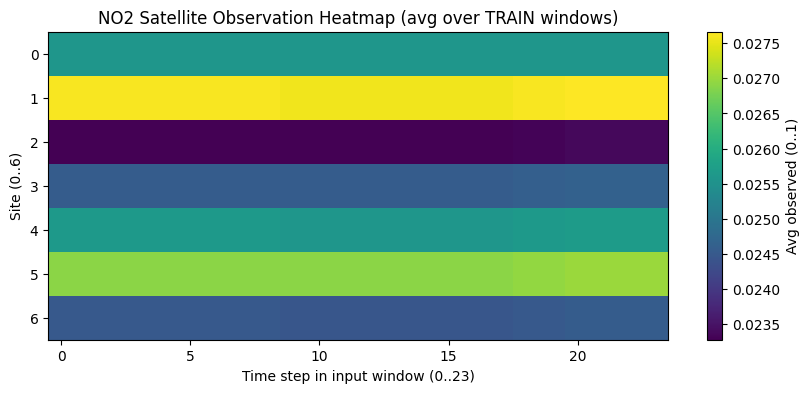

In [11]:
"""
Cell 9: Preprocessing Heatmap (Satellite observation pattern)

We visualize one satellite channel's "is_obs" feature across:
- y-axis: sites (7)
- x-axis: time steps in the input window (Tin=24)
value = average observation (0..1) over the TRAIN set

This is a sanity + comparison plot you can match with your single-site heatmaps.
"""

import numpy as np
import matplotlib.pyplot as plt

# Find indices of the engineered satellite features in feature_cols_geo
idx_no2_isobs = feature_cols_geo.index("NO2_satellite_is_obs")
idx_hcho_isobs = feature_cols_geo.index("HCHO_satellite_is_obs")
idx_ratio_isobs = feature_cols_geo.index("ratio_satellite_is_obs")

# Choose which to plot (start with NO2 satellite obs)
idx_plot = idx_no2_isobs
title = "NO2 Satellite Observation Heatmap (avg over TRAIN windows)"

# Extract: (N, Tin, S) for that feature
vals = X_train_geo[..., idx_plot]   # (N, Tin, S)

# Average over samples -> (Tin, S)
avg = vals.mean(axis=0)  # (Tin, S)

# Plot heatmap: sites on y-axis, time on x-axis
plt.figure(figsize=(10, 4))
plt.imshow(avg.T, aspect="auto")
plt.colorbar(label="Avg observed (0..1)")
plt.xlabel("Time step in input window (0..23)")
plt.ylabel("Site (0..6)")
plt.title(title)
plt.show()

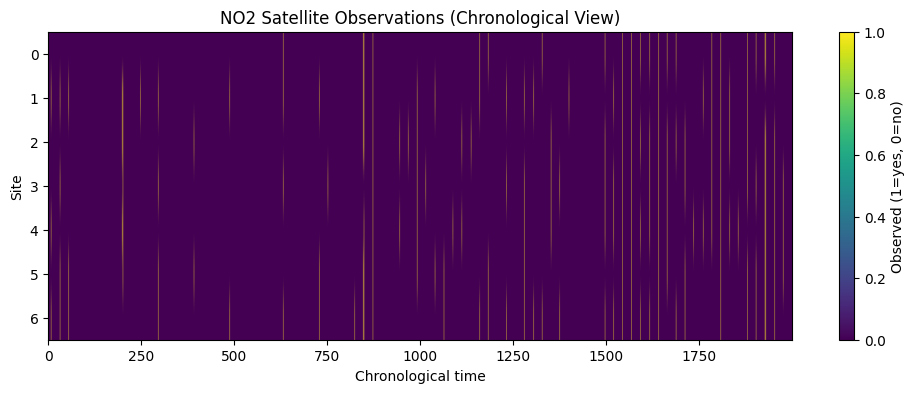

In [12]:
"""
Cell 10: Chronological Satellite Observation Heatmap

Instead of averaging across windows,
we visualize satellite observation across real chronological time.

This shows true sparsity structure across sites.
"""

import matplotlib.pyplot as plt

# Reload aligned (pre-window) training data
ALIGNED_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "train_aligned.npz")
aligned = np.load(ALIGNED_PATH)

X_aligned = aligned["X"]              # (T, S, F)
X_mask_aligned = aligned["X_mask"]    # (T, S, F)

# Find NO2 satellite index
idx_no2sat = feature_cols.index("NO2_satellite")

# Extract observation mask
obs = X_mask_aligned[..., idx_no2sat]  # (T, S)

# Select a subset of timeline for clarity (first 2000 timesteps)
T_plot = 2000
obs_plot = obs[:T_plot]  # (T_plot, S)

plt.figure(figsize=(12, 4))
plt.imshow(obs_plot.T, aspect="auto")
plt.colorbar(label="Observed (1=yes, 0=no)")
plt.xlabel("Chronological time")
plt.ylabel("Site")
plt.title("NO2 Satellite Observations (Chronological View)")
plt.show()

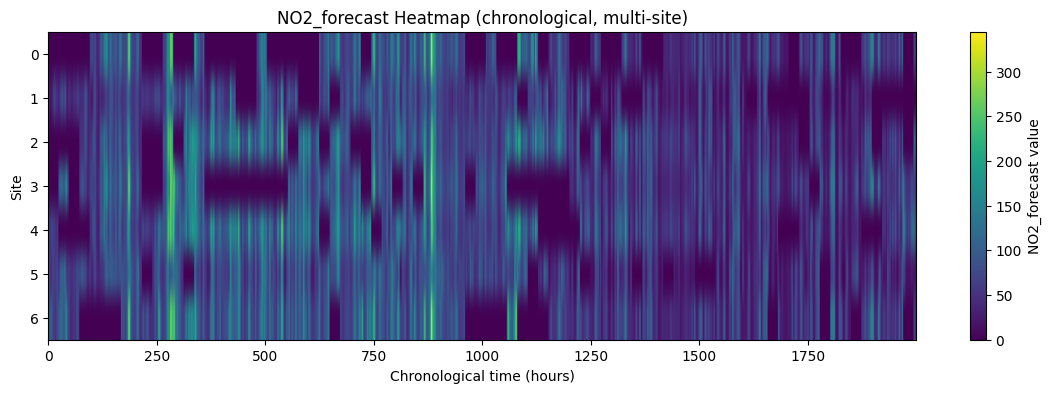

In [13]:
"""
Cell 11A: Feature-value heatmap (AirTransformer-style)

Plot a dense feature (NO2_forecast) across chronological time vs sites.
This should look similar to AirTransformer heatmaps.
"""

import os
import numpy as np
import matplotlib.pyplot as plt

ALIGNED_PATH = os.path.join(PROJECT_ROOT, "data", "processed", "train_aligned.npz")
aligned = np.load(ALIGNED_PATH, allow_pickle=True)

X_aligned = aligned["X"]  # (T, S, F)

# IMPORTANT: feature_cols currently includes the original 14 features
# (from the raw splits file). That matches train_aligned.npz layout.
idx_no2f = feature_cols.index("NO2_forecast")

T_plot = 2000  # change to 5000 if you want more
vals = X_aligned[:T_plot, :, idx_no2f]  # (T_plot, S)

plt.figure(figsize=(14, 4))
plt.imshow(vals.T, aspect="auto")
plt.colorbar(label="NO2_forecast value")
plt.xlabel("Chronological time (hours)")
plt.ylabel("Site")
plt.title("NO2_forecast Heatmap (chronological, multi-site)")
plt.show()

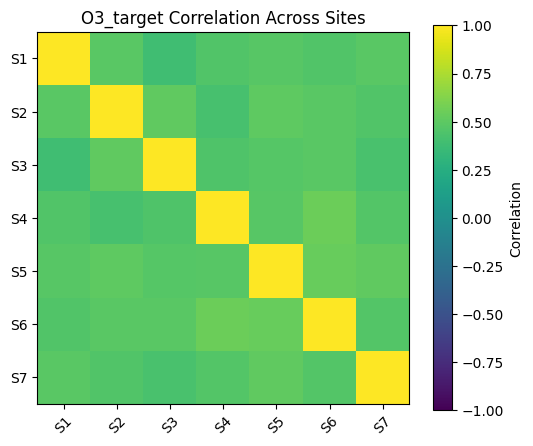

In [14]:
"""
Cell 11B: Site-to-site correlation heatmap (targets)

Compute correlation between sites based on O3_target (aligned train).
This gives a station correlation matrix like your example.
"""

import numpy as np
import matplotlib.pyplot as plt

Y_aligned = aligned["Y"]  # (T, S, 2)
target_cols = list(aligned["target_cols"])

idx_o3 = target_cols.index("O3_target")

# Shape (T, S)
o3 = Y_aligned[:, :, idx_o3]

# Correlation across sites -> (S, S)
corr = np.corrcoef(o3.T)

plt.figure(figsize=(6, 5))
plt.imshow(corr, aspect="equal", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(o3.shape[1]), [f"S{i+1}" for i in range(o3.shape[1])], rotation=45)
plt.yticks(range(o3.shape[1]), [f"S{i+1}" for i in range(o3.shape[1])])
plt.title("O3_target Correlation Across Sites")
plt.show()

Distance matrix (km) stats:
min (non-zero): 6.8102511818601865 max: 36.43574864323224

Sigma (km): 17.705436397111043
A_dist range: 0.12033870760522879 to 1.0


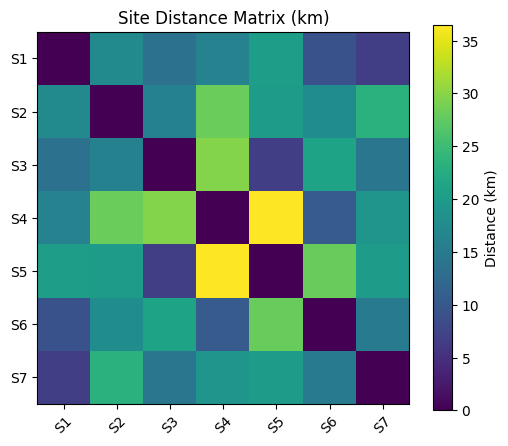

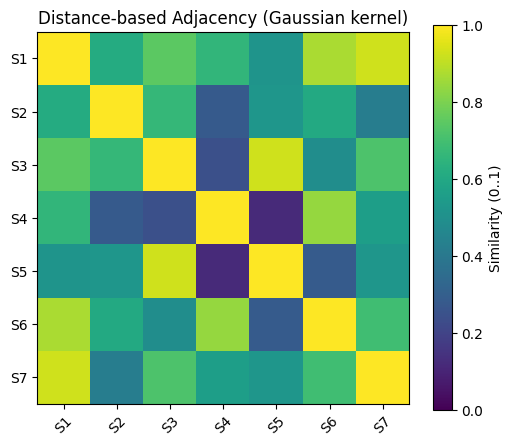

In [15]:
"""
Cell 12: Build distance-based adjacency (spatial graph)

Steps:
1) Compute pairwise Haversine distance between sites (km)
2) Convert distance -> similarity using Gaussian kernel
3) Produce A_dist (SxS) adjacency weights
4) Plot distance matrix + adjacency matrix
"""

import numpy as np
import matplotlib.pyplot as plt

# latlon is (S, 2) with columns [lat, lon] from Cell 8
# Ensure it's float64 for stable trig ops
latlon_deg = latlon.astype(np.float64)

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between two points on Earth (km).
    """
    R = 6371.0  # Earth radius (km)
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2.0)**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

S = latlon_deg.shape[0]
D = np.zeros((S, S), dtype=np.float64)

for i in range(S):
    for j in range(S):
        D[i, j] = haversine_km(latlon_deg[i,0], latlon_deg[i,1], latlon_deg[j,0], latlon_deg[j,1])

print("Distance matrix (km) stats:")
print("min (non-zero):", D[D>0].min(), "max:", D.max())

# Convert distances -> similarity (Gaussian kernel)
# sigma controls how fast similarity decays with distance.
# A good default is median non-zero distance.
sigma = np.median(D[D > 0])
A_dist = np.exp(-(D**2) / (2 * sigma**2))

# Force diagonal = 1
np.fill_diagonal(A_dist, 1.0)

print("\nSigma (km):", sigma)
print("A_dist range:", A_dist.min(), "to", A_dist.max())

# Plot distance matrix
plt.figure(figsize=(6,5))
plt.imshow(D, aspect="equal")
plt.colorbar(label="Distance (km)")
plt.xticks(range(S), [f"S{i+1}" for i in range(S)], rotation=45)
plt.yticks(range(S), [f"S{i+1}" for i in range(S)])
plt.title("Site Distance Matrix (km)")
plt.show()

# Plot adjacency/similarity matrix
plt.figure(figsize=(6,5))
plt.imshow(A_dist, aspect="equal", vmin=0, vmax=1)
plt.colorbar(label="Similarity (0..1)")
plt.xticks(range(S), [f"S{i+1}" for i in range(S)], rotation=45)
plt.yticks(range(S), [f"S{i+1}" for i in range(S)])
plt.title("Distance-based Adjacency (Gaussian kernel)")
plt.show()

A_corr range: 0.0 to 1.0


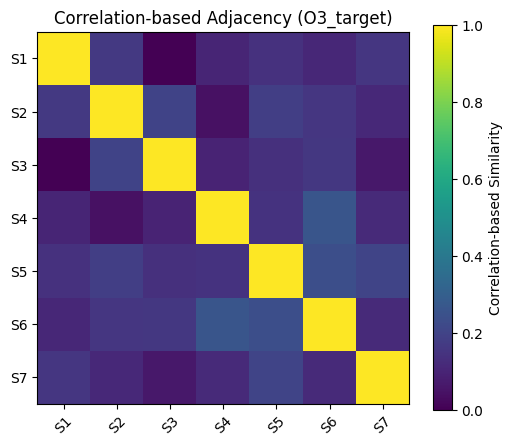

In [16]:
"""
Cell 13: Correlation-based adjacency (train-only, no leakage)

We build adjacency from O3_target correlation across sites.
This captures dynamic similarity rather than geographic distance.
"""

import numpy as np
import matplotlib.pyplot as plt

# Using corr from previous correlation cell
# corr shape = (S, S)

# Option 1: Use positive correlations only
A_corr = np.maximum(corr, 0.0)

# Normalize to [0,1]
A_corr = (A_corr - A_corr.min()) / (A_corr.max() - A_corr.min())

# Force diagonal = 1
np.fill_diagonal(A_corr, 1.0)

print("A_corr range:", A_corr.min(), "to", A_corr.max())

plt.figure(figsize=(6,5))
plt.imshow(A_corr, aspect="equal", vmin=0, vmax=1)
plt.colorbar(label="Correlation-based Similarity")
plt.xticks(range(S), [f"S{i+1}" for i in range(S)], rotation=45)
plt.yticks(range(S), [f"S{i+1}" for i in range(S)])
plt.title("Correlation-based Adjacency (O3_target)")
plt.show()

A_final range: 0.13260557647365837 to 1.0
Row sums after normalization: [1. 1. 1. 1. 1. 1. 1.]


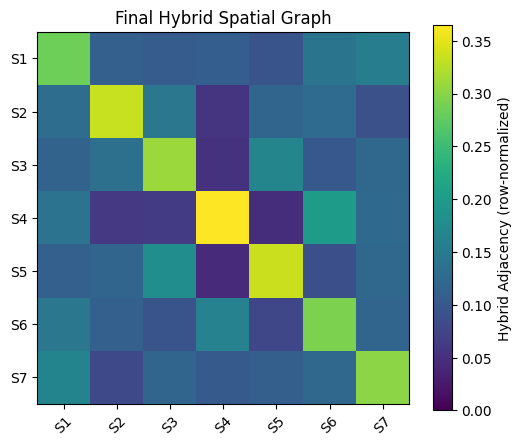


✅ Saved:
 - adjacency_distance.npy
 - adjacency_corr.npy
 - adjacency_final.npy


In [17]:
"""
Cell 14: Combine distance + correlation graphs and save

We create:
A_final = alpha * A_dist + (1 - alpha) * A_corr

Then we:
1) Normalize rows (optional but recommended for GNN)
2) Save adjacency matrices to disk
"""

import os
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.5  # equal weighting

A_final = alpha * A_dist + (1 - alpha) * A_corr

# Optional: row-normalize (common in GNN)
row_sums = A_final.sum(axis=1, keepdims=True)
A_final_norm = A_final / row_sums

print("A_final range:", A_final.min(), "to", A_final.max())
print("Row sums after normalization:", A_final_norm.sum(axis=1))

# Plot hybrid adjacency
plt.figure(figsize=(6,5))
plt.imshow(A_final_norm, aspect="equal", vmin=0, vmax=A_final_norm.max())
plt.colorbar(label="Hybrid Adjacency (row-normalized)")
plt.xticks(range(S), [f"S{i+1}" for i in range(S)], rotation=45)
plt.yticks(range(S), [f"S{i+1}" for i in range(S)])
plt.title("Final Hybrid Spatial Graph")
plt.show()

# ---- Save matrices ----
GRAPH_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(GRAPH_DIR, exist_ok=True)

np.save(os.path.join(GRAPH_DIR, "adjacency_distance.npy"), A_dist)
np.save(os.path.join(GRAPH_DIR, "adjacency_corr.npy"), A_corr)
np.save(os.path.join(GRAPH_DIR, "adjacency_final.npy"), A_final_norm)

print("\n✅ Saved:")
print(" - adjacency_distance.npy")
print(" - adjacency_corr.npy")
print(" - adjacency_final.npy")

In [18]:
"""
Cell 15: Phase D - Normalize only engineered continuous features (age + lat/lon)

Goal:
-----
Keep:
- cyclical features (sin/cos) as-is (already in [-1, 1])
- is_obs features as-is (0/1)

Standardize:
- *_age features (0..Tin)
- site_lat, site_lon

Then save:
- data/processed/splits_final_Tin24_Tout6_stride1.npz
- configs/final_feature_scaler.json

This makes the dataset "model-ready" and CV-grade.
"""

import os
import json
import numpy as np

# We are currently at:
# X_train_geo, X_val_geo, X_test_geo
# feature_cols_geo
# masks: X_mask_train_geo, X_mask_val_geo, X_mask_test_geo

# Identify columns to standardize
cols_to_scale = [
    "NO2_satellite_age",
    "HCHO_satellite_age",
    "ratio_satellite_age",
    "site_lat",
    "site_lon",
]

scale_indices = [feature_cols_geo.index(c) for c in cols_to_scale]
print("Scaling these features:", list(zip(cols_to_scale, scale_indices)))

def fit_partial_scaler(X, X_mask, idxs, eps=1e-6):
    """
    Fit mean/std for only selected feature indices (train-only), mask-aware.
    Returns mean/std arrays of shape (F,) where non-selected features have mean=0, std=1.
    """
    F = X.shape[-1]
    mean = np.zeros((F,), dtype=np.float32)
    std  = np.ones((F,), dtype=np.float32)

    X_flat = X.reshape(-1, F)
    M_flat = X_mask.reshape(-1, F)

    for f in idxs:
        valid = M_flat[:, f] > 0.5
        vals = X_flat[valid, f]
        if vals.size == 0:
            mean[f] = 0.0
            std[f] = 1.0
        else:
            mean[f] = vals.mean().astype(np.float32)
            s = vals.std().astype(np.float32)
            std[f] = s if s > eps else 1.0
    return mean, std

mean_final, std_final = fit_partial_scaler(X_train_geo, X_mask_train_geo, scale_indices)

def apply_featurewise_scaler(X, mean, std):
    return (X - mean.reshape((1,) * (X.ndim - 1) + (-1,))) / std.reshape((1,) * (X.ndim - 1) + (-1,))

X_train_ready = apply_featurewise_scaler(X_train_geo, mean_final, std_final)
X_val_ready   = apply_featurewise_scaler(X_val_geo,   mean_final, std_final)
X_test_ready  = apply_featurewise_scaler(X_test_geo,  mean_final, std_final)

# Save final dataset
FINAL_NPZ = os.path.join(PROJECT_ROOT, "data", "processed", "splits_final_Tin24_Tout6_stride1.npz")
np.savez_compressed(
    FINAL_NPZ,
    X_train=X_train_ready, Y_train=Y_train, X_mask_train=X_mask_train_geo, Y_mask_train=data["Y_mask_train"],
    X_val=X_val_ready,     Y_val=Y_val,     X_mask_val=X_mask_val_geo,     Y_mask_val=data["Y_mask_val"],
    X_test=X_test_ready,   Y_test=Y_test,   X_mask_test=X_mask_test_geo,   Y_mask_test=data["Y_mask_test"],
    sites=data["sites"],
    feature_cols=np.array(feature_cols_geo, dtype=object),
    target_cols=data["target_cols"],
    tin=data["tin"], tout=data["tout"], stride=data["stride"],
)

print("✅ Saved final model-ready splits to:")
print(FINAL_NPZ)

# Save final scaler config (per-feature mean/std, passthrough for others)
FINAL_SCALER_JSON = os.path.join(PROJECT_ROOT, "configs", "final_feature_scaler.json")
scaler_payload = {
    "type": "partial_standard_scaler_train_only",
    "feature_cols": feature_cols_geo,
    "scaled_features": cols_to_scale,
    "mean": mean_final.tolist(),
    "std": std_final.tolist(),
}

with open(FINAL_SCALER_JSON, "w") as f:
    json.dump(scaler_payload, f, indent=2)

print("\n✅ Saved final feature scaler to:")
print(FINAL_SCALER_JSON)

# Sanity check: one of the scaled features should be ~0 mean, ~1 std in train
fcheck = feature_cols_geo.index("site_lon")
vals = X_train_ready[..., fcheck][X_mask_train_geo[..., fcheck] > 0.5]
print("\nSanity check for site_lon (train):")
print("Mean ~0:", float(vals.mean()))
print("Std  ~1:", float(vals.std()))

Scaling these features: [('NO2_satellite_age', 21), ('HCHO_satellite_age', 23), ('ratio_satellite_age', 25), ('site_lat', 26), ('site_lon', 27)]
✅ Saved final model-ready splits to:
/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)/data/processed/splits_final_Tin24_Tout6_stride1.npz

✅ Saved final feature scaler to:
/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)/configs/final_feature_scaler.json

Sanity check for site_lon (train):
Mean ~0: -7.756712605555549e-09
Std  ~1: 1.0


In [2]:
"""
Cell 16: Fit target scaler (train-only) and save

We scale Y targets (O3_target, NO2_target) using training set only.
This improves training stability and generalization.

We do NOT modify the saved X file here; we create a new npz with Y scaled.
"""

import os, json
import numpy as np
PROJECT_ROOT = "/Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)"

FINAL_NPZ = os.path.join(PROJECT_ROOT, "data", "processed", "splits_final_Tin24_Tout6_stride1.npz")
data_final = np.load(FINAL_NPZ, allow_pickle=True)

Y_train = data_final["Y_train"]         # (N, Tout, S, 2)
Y_mask_train = data_final["Y_mask_train"]

Y_val = data_final["Y_val"]
Y_mask_val = data_final["Y_mask_val"]

Y_test = data_final["Y_test"]
Y_mask_test = data_final["Y_mask_test"]

def fit_target_scaler(Y, Y_mask, eps=1e-6):
    """
    Fit mean/std per target channel using valid values only.
    Returns mean/std arrays of shape (C,)
    """
    C = Y.shape[-1]
    mean = np.zeros((C,), dtype=np.float32)
    std  = np.ones((C,), dtype=np.float32)

    for c in range(C):
        valid = Y_mask[..., c] > 0.5
        vals = Y[..., c][valid]
        mean[c] = vals.mean().astype(np.float32)
        s = vals.std().astype(np.float32)
        std[c] = s if s > eps else 1.0

    return mean, std

y_mean, y_std = fit_target_scaler(Y_train, Y_mask_train)

print("Target mean:", y_mean)
print("Target std :", y_std)

def apply_target_scaler(Y, mean, std):
    return (Y - mean.reshape((1,1,1,-1))) / std.reshape((1,1,1,-1))

Y_train_s = apply_target_scaler(Y_train, y_mean, y_std)
Y_val_s   = apply_target_scaler(Y_val,   y_mean, y_std)
Y_test_s  = apply_target_scaler(Y_test,  y_mean, y_std)

# Save a new npz including scaled Y
OUT_NPZ_Y = os.path.join(PROJECT_ROOT, "data", "processed", "splits_final_Yscaled_Tin24_Tout6_stride1.npz")

np.savez_compressed(
    OUT_NPZ_Y,
    X_train=data_final["X_train"], X_mask_train=data_final["X_mask_train"], Y_train=Y_train_s, Y_mask_train=Y_mask_train,
    X_val=data_final["X_val"],     X_mask_val=data_final["X_mask_val"],     Y_val=Y_val_s,     Y_mask_val=Y_mask_val,
    X_test=data_final["X_test"],   X_mask_test=data_final["X_mask_test"],   Y_test=Y_test_s,   Y_mask_test=Y_mask_test,
    sites=data_final["sites"],
    feature_cols=data_final["feature_cols"],
    target_cols=data_final["target_cols"],
    tin=data_final["tin"], tout=data_final["tout"], stride=data_final["stride"],
)

print("✅ Saved:", OUT_NPZ_Y)

# Save target scaler json
SCALER_PATH = os.path.join(PROJECT_ROOT, "configs", "target_scaler.json")
payload = {"mean": y_mean.tolist(), "std": y_std.tolist(), "targets": list(data_final["target_cols"])}
with open(SCALER_PATH, "w") as f:
    json.dump(payload, f, indent=2)

print("✅ Saved target scaler:", SCALER_PATH)

# Sanity: scaled train targets should have mean ~0, std ~1 (masked)
for c, name in enumerate(list(data_final["target_cols"])):
    valid = Y_mask_train[..., c] > 0.5
    vals = Y_train_s[..., c][valid]
    print(name, "scaled mean:", float(vals.mean()), "scaled std:", float(vals.std()))

Target mean: [31.967495 39.13277 ]
Target std : [34.72024  29.908665]
✅ Saved: /Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)/data/processed/splits_final_Yscaled_Tin24_Tout6_stride1.npz
✅ Saved target scaler: /Users/siddharthbose/Desktop/Projects/Luftwächter(multisite_transformer)/configs/target_scaler.json
O3_target scaled mean: -6.166776245208894e-08 scaled std: 1.0
NO2_target scaled mean: 3.1519078902420006e-08 scaled std: 1.0
